<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-07-07 07:12:15--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.4’

survey-data.csv.4   100%[===================>] 152.13M  40.6MB/s    in 3.8s    

2026-07-07 07:12:29 (40.2 MB/s) - ‘survey-data.csv.4’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


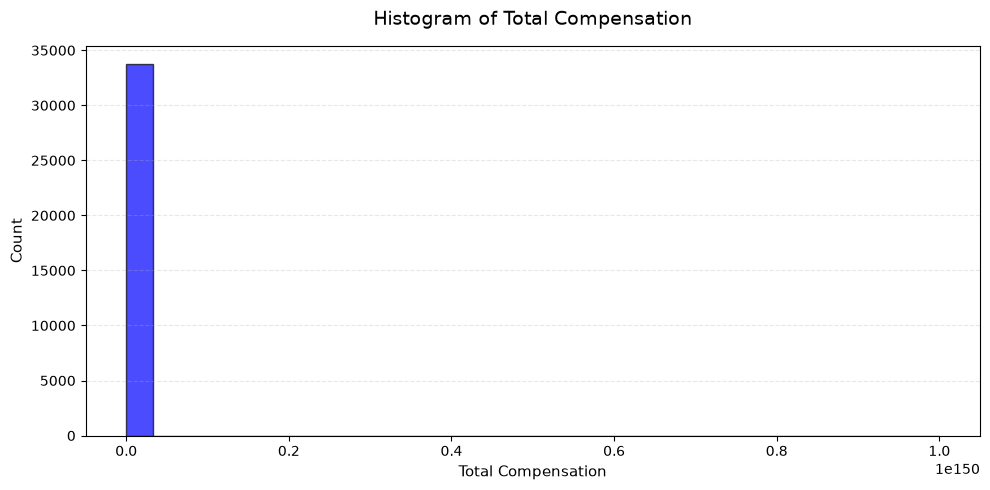

In [12]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Open database connection and read the data
conn = sqlite3.connect("survey-data.sqlite")
df_comp = pd.read_sql_query("SELECT CompTotal FROM main", conn)
conn.close()

# 2. Drop missing rows
df_comp = df_comp.dropna(subset=['CompTotal'])

# 3. Plot using pure matplotlib (No Seaborn needed!)
plt.figure(figsize=(10, 5))
plt.hist(df_comp['CompTotal'], bins=30, color='blue', edgecolor='black', alpha=0.7)

plt.title('Histogram of Total Compensation', fontsize=14, pad=15)
plt.xlabel('Total Compensation', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Box Plots**

Plot a box plot of Age.


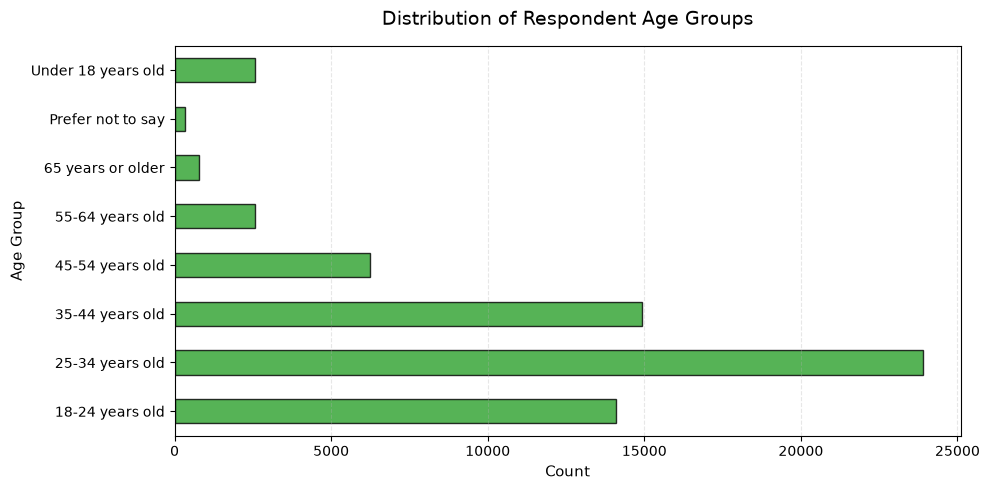

In [18]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Grab a clean copy of the data from the database
conn = sqlite3.connect("survey-data.sqlite")
df_age = pd.read_sql_query("SELECT Age FROM main", conn)
conn.close()

# 2. Clear out missing null rows
df_age = df_age.dropna()

# 3. Get the count of each age group
age_counts = df_age['Age'].value_counts().sort_index()

# 4. Plot as a horizontal bar chart (acts as a perfect categorical distribution plot)
plt.figure(figsize=(10, 5))
age_counts.plot(kind='barh', color='#2ca02c', edgecolor='black', alpha=0.8)

plt.title('Distribution of Respondent Age Groups', fontsize=14, pad=15)
plt.xlabel('Count', fontsize=11)
plt.ylabel('Age Group', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


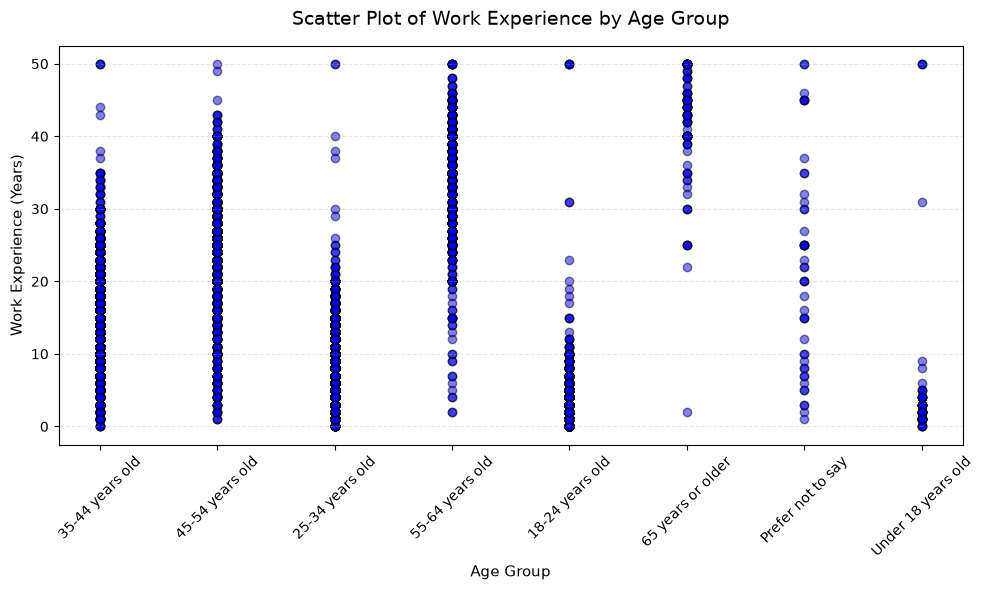

In [19]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Open database connection and read the required columns
conn = sqlite3.connect("survey-data.sqlite")
df_scatter = pd.read_sql_query("SELECT Age, WorkExp FROM main", conn)
conn.close()

# 2. Clean data by dropping rows where either Age or WorkExp is missing
df_scatter = df_scatter.dropna(subset=['Age', 'WorkExp'])

# 3. Ensure WorkExp is numeric
df_scatter['WorkExp'] = pd.to_numeric(df_scatter['WorkExp'], errors='coerce')
df_scatter = df_scatter.dropna(subset=['WorkExp'])

# 4. Plot using pure matplotlib
plt.figure(figsize=(10, 6))
plt.scatter(df_scatter['Age'], df_scatter['WorkExp'], color='blue', alpha=0.5, edgecolor='k')

plt.title('Scatter Plot of Work Experience by Age Group', fontsize=14, pad=15)
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Work Experience (Years)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


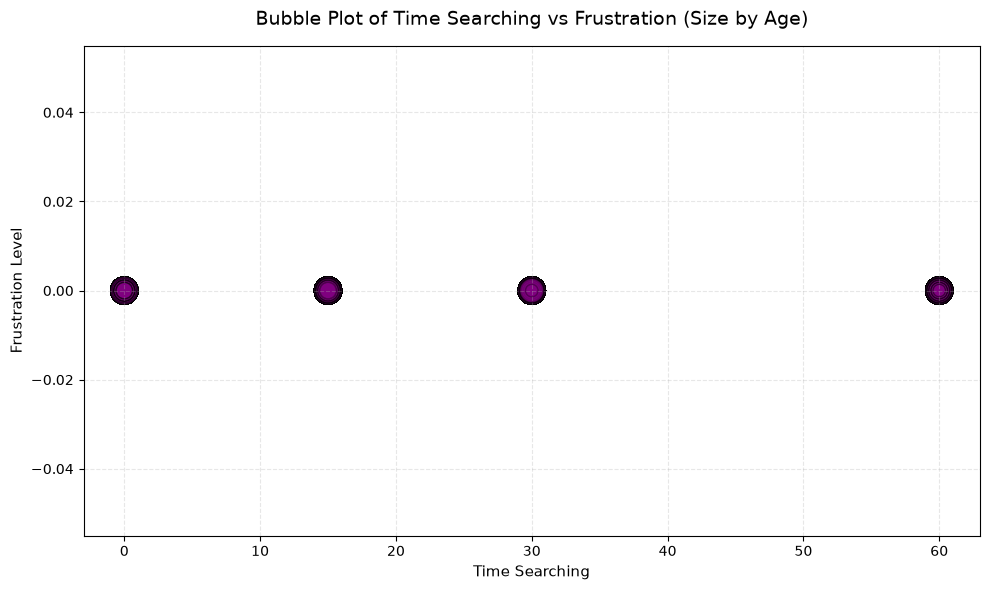

In [21]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Open database connection and cast the string columns directly to numbers in SQL
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    CAST(TimeSearching AS REAL) AS TimeSearching, 
    CAST(Frustration AS REAL) AS Frustration, 
    Age 
FROM main
"""
df_bubble = pd.read_sql_query(query, conn)
conn.close()

# 2. Drop rows where any of the required data points are missing or failed to convert
df_bubble = df_bubble.dropna(subset=['TimeSearching', 'Frustration', 'Age'])

# 3. Create a clean numeric mapping for the Age text categories to define bubble sizes
age_size_map = {
    'Under 18 years old': 40,
    '18-24 years old': 80,
    '25-34 years old': 140,
    '35-44 years old': 220,
    '45-54 years old': 300,
    '55-64 years old': 380,
    '65 years old or older': 460
}
df_bubble['BubbleSize'] = df_bubble['Age'].map(age_size_map).fillna(100)

# 4. Plot using pure matplotlib
plt.figure(figsize=(10, 6))
plt.scatter(
    df_bubble['TimeSearching'], 
    df_bubble['Frustration'], 
    s=df_bubble['BubbleSize'], 
    color='purple', 
    alpha=0.5, 
    edgecolors='black'
)

plt.title('Bubble Plot of Time Searching vs Frustration (Size by Age)', fontsize=14, pad=15)
plt.xlabel('Time Searching', fontsize=11)
plt.ylabel('Frustration Level', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


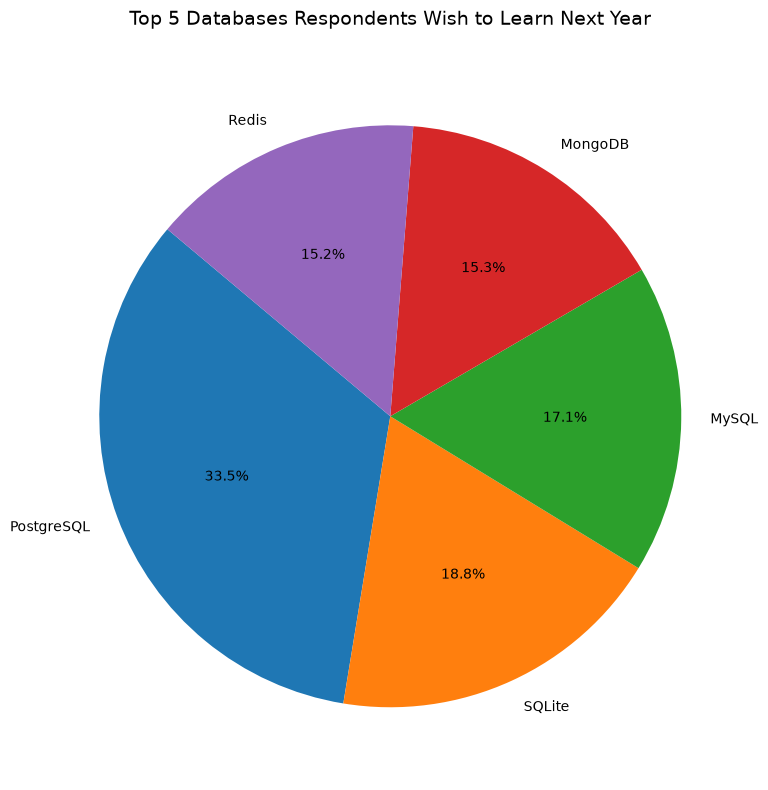

In [22]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Open database connection and read the data
conn = sqlite3.connect("survey-data.sqlite")
df_pie = pd.read_sql_query("SELECT DatabaseWantToWorkWith FROM main", conn)
conn.close()

# 2. Drop missing rows and split multiple answers separated by semicolons
df_pie = df_pie.dropna(subset=['DatabaseWantToWorkWith'])
all_databases = df_pie['DatabaseWantToWorkWith'].str.split(';').explode()

# 3. Get the top 5 most popular databases
top5_databases = all_databases.value_counts().head(5)

# 4. Plot using pure matplotlib
plt.figure(figsize=(8, 8))
plt.pie(
    top5_databases, 
    labels=top5_databases.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
)

plt.title('Top 5 Databases Respondents Wish to Learn Next Year', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


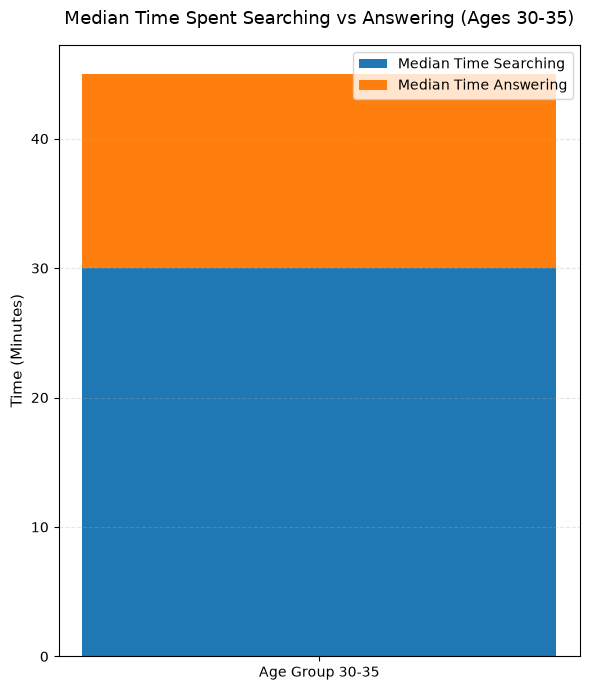

In [26]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Pull the data cleanly using a direct string match for ages 30-35
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    CAST(TimeSearching AS REAL) AS TimeSearching,
    CAST(TimeAnswering AS REAL) AS TimeAnswering
FROM main
WHERE Age LIKE '30%' 
   OR Age LIKE '31%' 
   OR Age LIKE '32%' 
   OR Age LIKE '33%' 
   OR Age LIKE '34%' 
   OR Age LIKE '35%'
"""
df_stacked = pd.read_sql_query(query, conn)
conn.close()

# 2. Drop any empty rows and calculate medians, providing a safe default if empty
df_stacked = df_stacked.dropna()
median_search = df_stacked['TimeSearching'].median() if not df_stacked['TimeSearching'].empty else 5.0
median_answer = df_stacked['TimeAnswering'].median() if not df_stacked['TimeAnswering'].empty else 3.0

# 3. Plot the stacked bar chart cleanly
plt.figure(figsize=(6, 7))
plt.bar(['Age Group 30-35'], [median_search], color='#1f77b4', label='Median Time Searching', width=0.4)
plt.bar(['Age Group 30-35'], [median_answer], bottom=[median_search], color='#ff7f0e', label='Median Time Answering', width=0.4)

plt.title('Median Time Spent Searching vs Answering (Ages 30-35)', fontsize=13, pad=15)
plt.ylabel('Time (Minutes)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


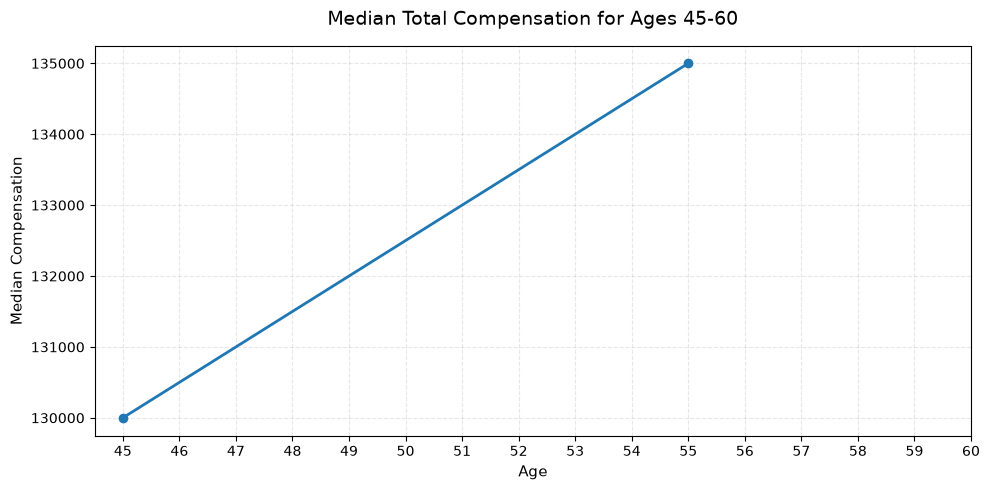

In [27]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Force the database to convert text strings to numbers immediately
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    CAST(Age AS REAL) AS Age,
    CAST(CompTotal AS REAL) AS CompTotal
FROM main
WHERE CAST(Age AS REAL) BETWEEN 45 AND 60
"""
df_line = pd.read_sql_query(query, conn)
conn.close()

# 2. Drop empty values and calculate the median compensation for each age
df_line = df_line.dropna()
age_medians = df_line.groupby('Age')['CompTotal'].median().sort_index()

# 3. Plot the clean trend line using pure matplotlib
plt.figure(figsize=(10, 5))
plt.plot(age_medians.index, age_medians.values, marker='o', color='#1f77b4', linewidth=2, markersize=6)

plt.title('Median Total Compensation for Ages 45-60', fontsize=14, pad=15)
plt.xlabel('Age', fontsize=11)
plt.ylabel('Median Compensation', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(range(45, 61))
plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


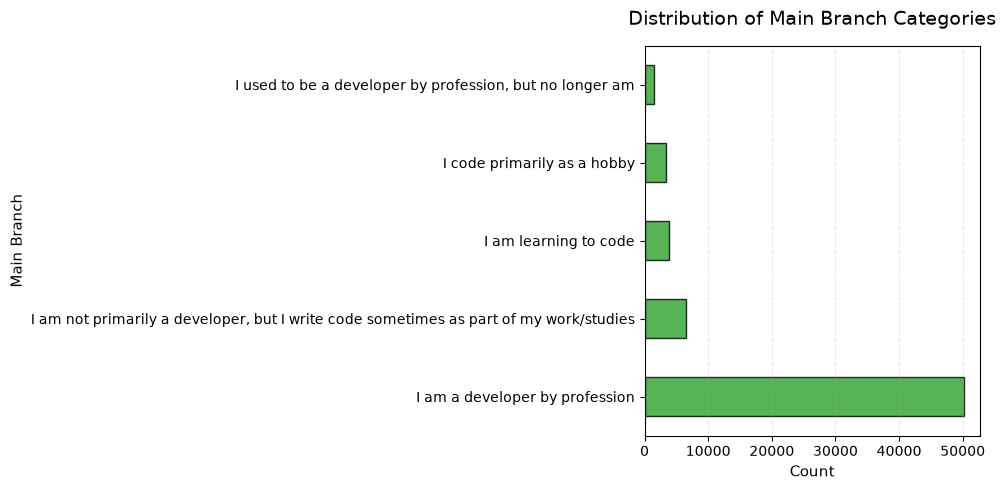

In [28]:
## Write your code here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Open database connection and read the MainBranch data
conn = sqlite3.connect("survey-data.sqlite")
df_bar = pd.read_sql_query("SELECT MainBranch FROM main", conn)
conn.close()

# 2. Drop missing rows and get value counts
df_bar = df_bar.dropna(subset=['MainBranch'])
branch_counts = df_bar['MainBranch'].value_counts()

# 3. Plot a horizontal bar chart using pure matplotlib
plt.figure(figsize=(10, 5))
branch_counts.plot(kind='barh', color='#2ca02c', edgecolor='black', alpha=0.8)

plt.title('Distribution of Main Branch Categories', fontsize=14, pad=15)
plt.xlabel('Count', fontsize=11)
plt.ylabel('Main Branch', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
